A unseen windows: 1034
B unseen windows: 1025
TARGET_T = 256
TARGET_S = 41
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
{
  "model_path": "/home/tonyliao/Location/source_train_runs/hybrid_source_A_best.keras",
  "A_unseen_windows": 1034,
  "B_unseen_windows": 1025,
  "num_locations": 7,
  "median_A_err": 2.9258129596710205,
  "median_B_err": 2.6772773265838623,
  "median_fused_err": 2.820237159729004,
  "median_A_weighted_err": 2.5850000381469727,
  "median_B_weighted_err": 2.8299028873443604,
  "median_fused_weighted_err": 2.6801822185516357
}
   anchor_label  gt_x  gt_y  A_num_windows  A_median_x  A_median_y  \
0        Center   3.0   4.0            148    2.449986    3.761612   
1        Corner   5.0   1.0            136    3.199187    2.781341   
2    Empty_Pred   0.0   0.0            147    2.478204    3.985437   
3  LeftDown_Far   1.0   7.0            147    2.303916    2.952073   
4   LeftUp_Near   2.0   2.5            145    2.796072    3.2510

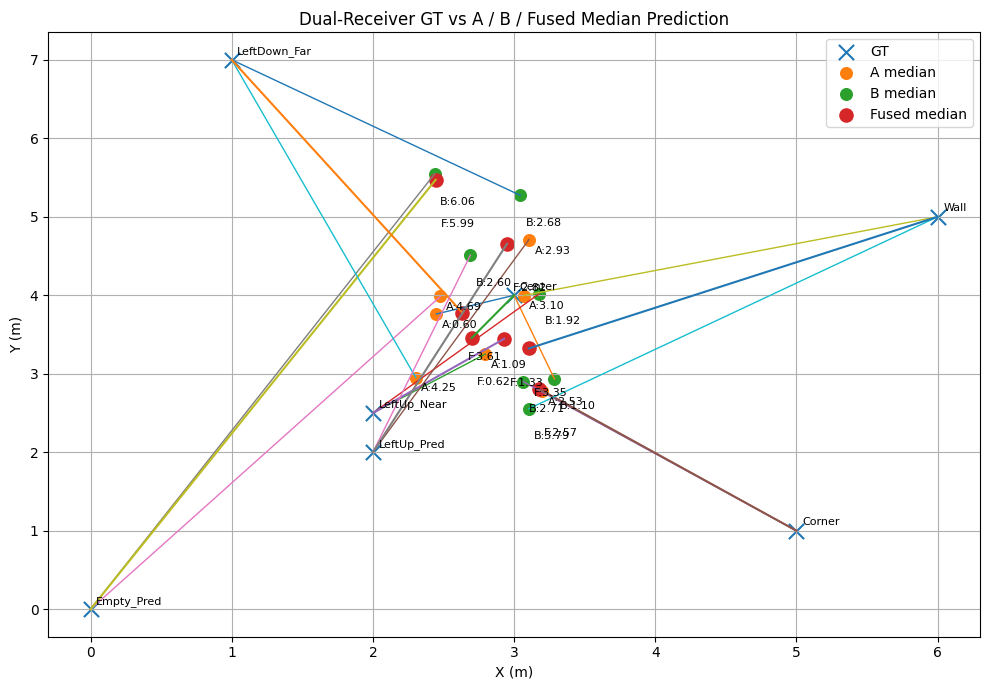

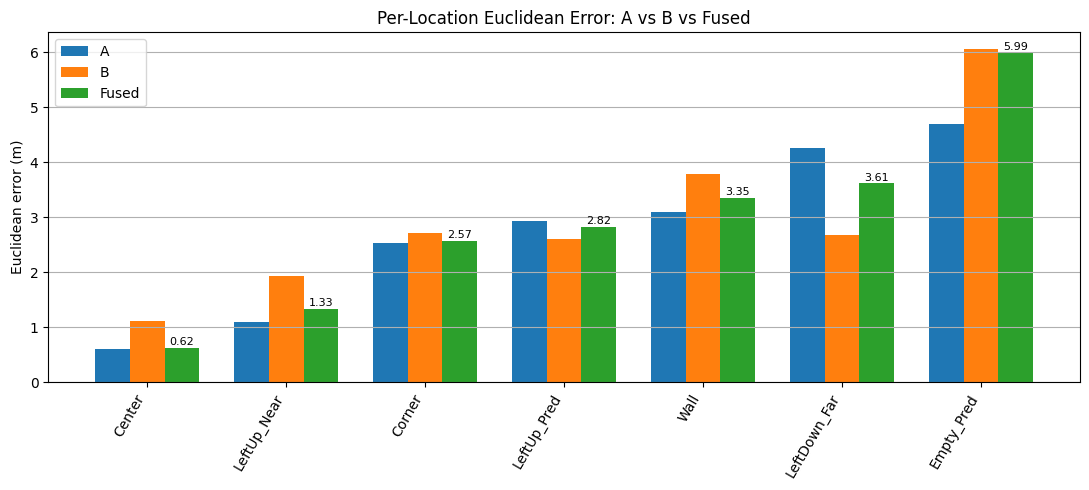

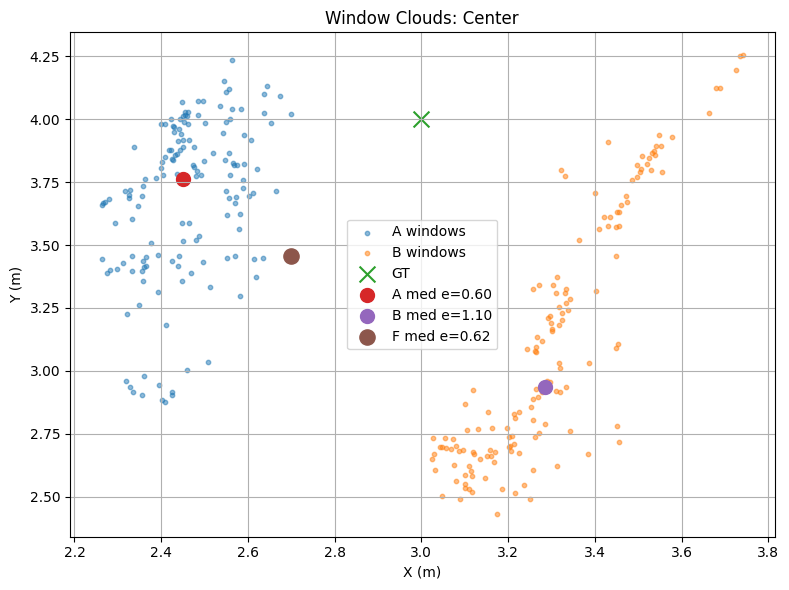

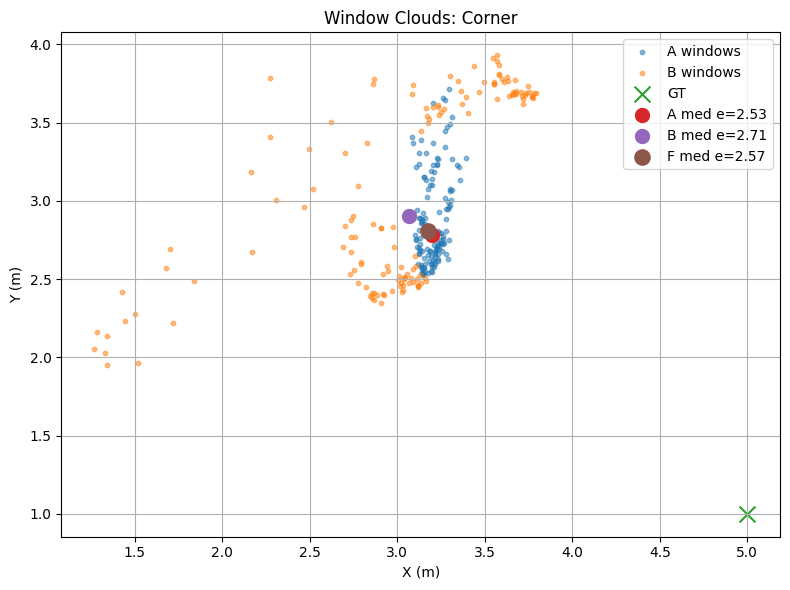

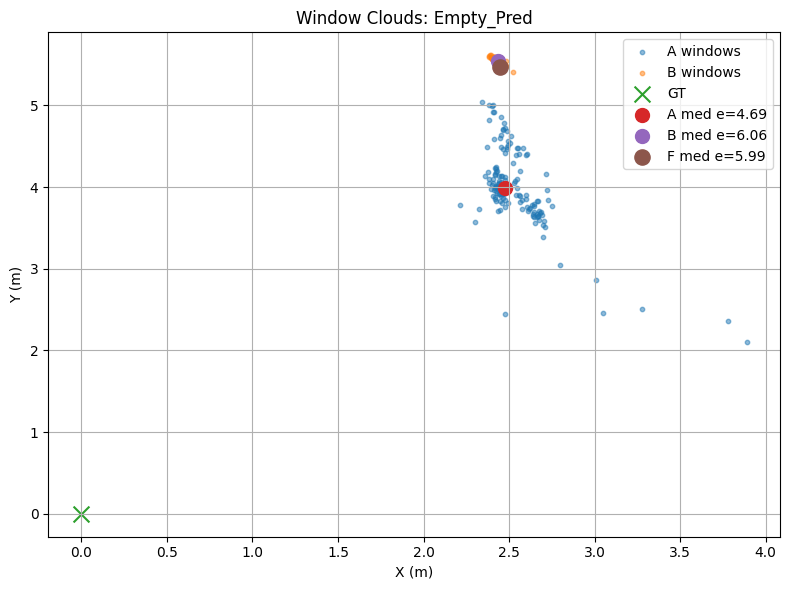

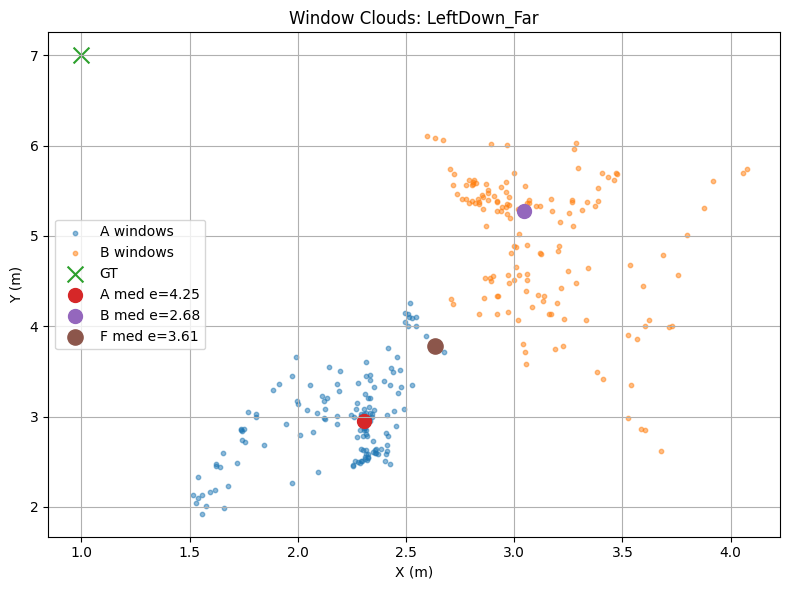

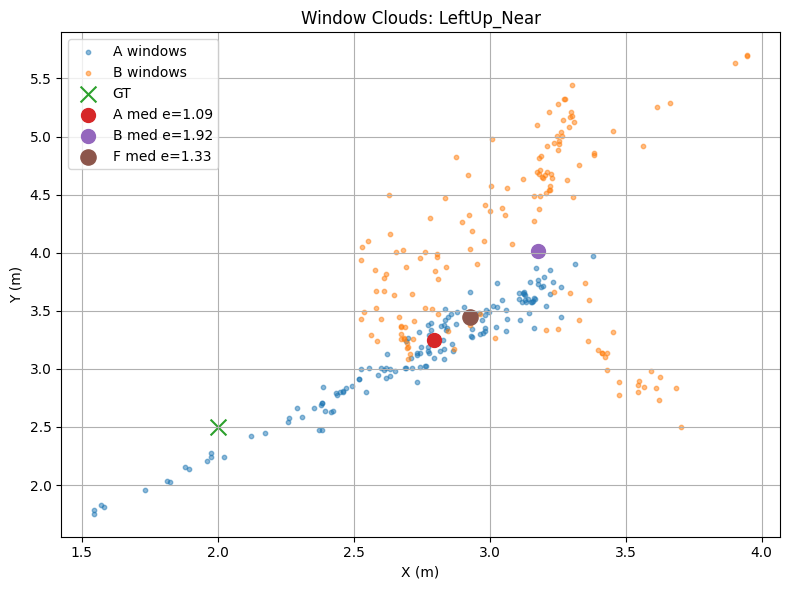

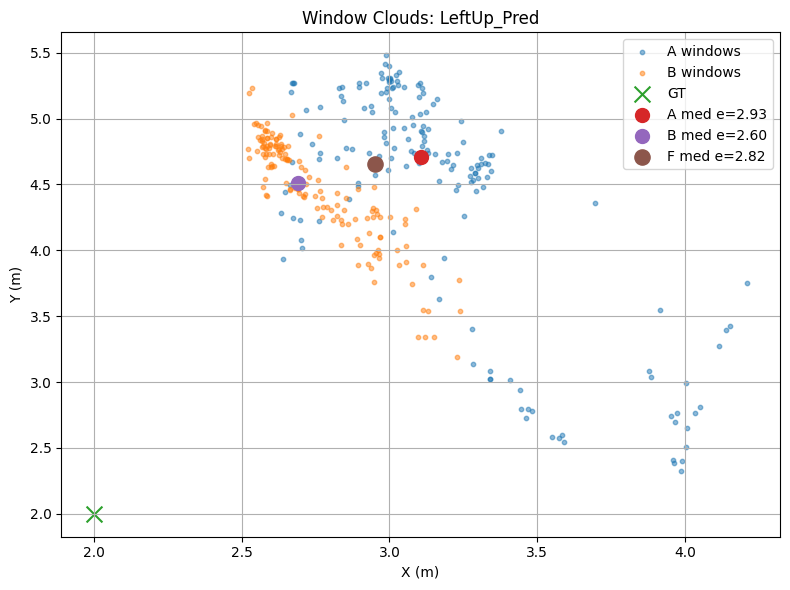

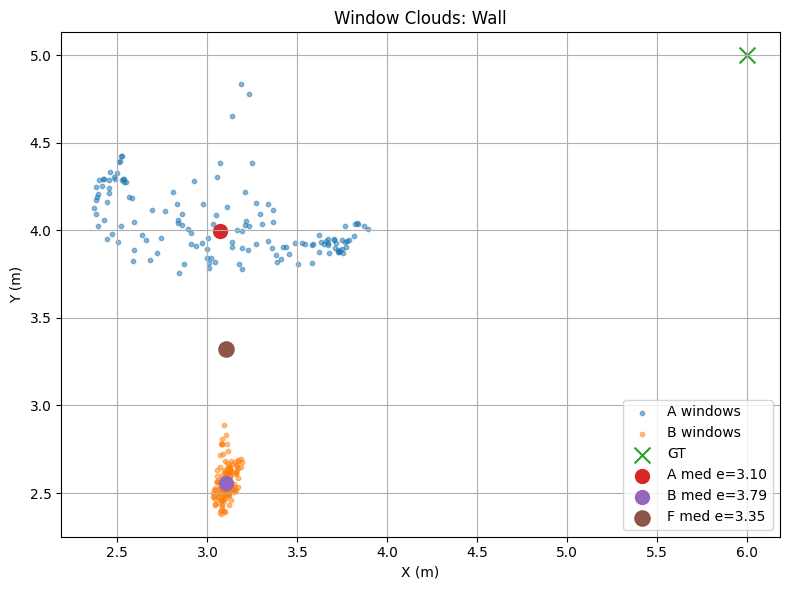

Saved outputs to: /home/tonyliao/Location/source_inference_unseen
Saved plots to: /home/tonyliao/Location/source_inference_unseen/plots


,anchor_label,gt_x,gt_y,pred_x,pred_y,gt_nearest_anchor,gt_to_anchor_dist,pred_nearest_anchor,pred_to_anchor_dist,anchor_match
0,Center,3.0,4.0,2.699930,3.456602,LeftMid,1.000000,LeftMid,0.886106,1
1,Corner,1.0,5.0,3.174147,2.808867,LeftDown,1.414214,MiddleUp,0.827401,0
2,Empty_Pred,0.0,0.0,2.444513,5.470882,Empty,0.000000,LeftDown,0.691055,0
3,LeftDown_Far,1.5,7.0,2.633799,3.777546,Corner_LeftDown,0.500000,LeftMid,0.671705,0
4,LeftUp_Near,2.0,2.5,2.928910,3.444892,LeftUp,0.500000,LeftMid,1.082136,0
5,LeftUp_Pred,2.0,2.0,2.949785,4.655494,LeftUp,0.000000,LeftMid,1.154020,0
6,Wall,6.0,5.0,3.103996,3.322308,Corner_RightDown,2.236068,RightMid,1.123428,0


In [2]:
# ============================================================
# 05_kde_infer_aggregate.ipynb
# Dual-receiver late-fusion inference on unseen locations
# A and B stay separate inputs; fuse only after prediction
# Uses new split files from 01_build_dataset.ipynb
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
DATA_ROOT = Path("/home/tonyliao/Location")
BUILD_DIR  = DATA_ROOT / "dataset_build_hybrid"
JOINT_DIR  = DATA_ROOT / "source_train_runs"
OUT_DIR    = DATA_ROOT / "source_inference_unseen"
PLOT_DIR   = OUT_DIR / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# final model from 04b
MODEL_PATH = JOINT_DIR / "hybrid_source_A_best.keras"

TARGET_T = 256
TARGET_S = None
BATCH_SIZE = 32

UNSEEN_LOCATIONS = {
    "Center",
    "Corner",
    "Empty_Pred",
    "LeftDown_Far",
    "LeftUp_Near",
    "LeftUp_Pred",
    "Wall",
}

CLASS_CENTER_MAP = {
    "Empty": [0.0, 0.0],
    "Center": [3.0, 4.0],
    "Corner": [5.0, 1.0],
    "Corner_LeftDown": [1.0, 7.0],
    "Corner_LeftUp": [1.0, 1.0],
    "Corner_RightDown": [5.0, 7.0],
    "Corner_RightUp": [5.0, 1.0],
    "Empty_Pred": [0.0, 0.0],
    "LeftDown": [2.0, 6.0],
    "LeftDown_Far": [1.0, 7.0],
    "LeftMid": [2.0, 4.0],
    "LeftUp": [2.0, 2.0],
    "LeftUp_Near": [2.0, 2.5],
    "LeftUp_Pred": [2.0, 2.0],
    "MiddleDown": [3.0, 6.0],
    "MiddleUp": [3.0, 2.0],
    "RightDown": [4.0, 6.0],
    "RightMid": [4.0, 4.0],
    "RightUp": [4.0, 2.0],
    "Wall": [6.0, 5.0],
}

# -----------------------------
# Helpers
# -----------------------------
def load_npz(path: Path):
    obj = np.load(path, allow_pickle=True)
    return {k: obj[k] for k in obj.files}

def ensure_3d(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 2:
        x = x[..., None]
    return x

def resize_to_target(x, target_t, target_s):
    x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
    x_tf = tf.image.resize(x_tf, size=(target_t, target_s), method="bilinear")
    return x_tf.numpy().astype(np.float32)

def zscore_per_sample(x):
    mu = np.mean(x, axis=(0, 1), keepdims=True)
    sd = np.std(x, axis=(0, 1), keepdims=True) + 1e-6
    return ((x - mu) / sd).astype(np.float32)

def load_amp(path):
    x = np.load(str(path)).astype(np.float32)
    return ensure_3d(x)

def load_pha(path, ref_shape=None):
    if path is None or str(path) == "":
        if ref_shape is None:
            raise ValueError("pha_path missing and ref_shape is None")
        return np.zeros(ref_shape, dtype=np.float32)

    p = Path(str(path))
    if not p.exists():
        if ref_shape is None:
            raise ValueError(f"pha_path does not exist: {path}")
        return np.zeros(ref_shape, dtype=np.float32)

    x = np.load(str(p)).astype(np.float32)
    return ensure_3d(x)

def preprocess_amp(path, target_t, target_s):
    x = load_amp(path)
    x = resize_to_target(x, target_t, target_s)
    x = zscore_per_sample(x)
    return x.astype(np.float32)

def preprocess_pha(path, amp_shape, target_t, target_s):
    x = load_pha(path, ref_shape=amp_shape)
    x = resize_to_target(x, target_t, target_s)
    x = zscore_per_sample(x)
    return x.astype(np.float32)

def xy_from_label(label_name):
    label_name = str(label_name)
    if label_name not in CLASS_CENTER_MAP:
        return np.array([np.nan, np.nan], dtype=np.float32)
    return np.asarray(CLASS_CENTER_MAP[label_name], dtype=np.float32)

def euclid(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    if np.any(~np.isfinite(a)) or np.any(~np.isfinite(b)):
        return np.nan
    return float(np.linalg.norm(a - b))

def window_weight(p_presence, p_class_max):
    return float(p_presence * p_class_max)

def median_xy(df_sub, xcol="final_x", ycol="final_y"):
    return np.array([
        np.median(df_sub[xcol].values),
        np.median(df_sub[ycol].values)
    ], dtype=np.float32)

def weighted_xy(df_sub, xcol="final_x", ycol="final_y", wcol="window_weight"):
    w = df_sub[wcol].values.astype(np.float32)
    if np.sum(w) <= 0:
        return median_xy(df_sub, xcol, ycol)
    return np.array([
        np.sum(df_sub[xcol].values * w) / np.sum(w),
        np.sum(df_sub[ycol].values * w) / np.sum(w),
    ], dtype=np.float32)

# -----------------------------
# Load unseen eval splits from new 01 outputs
# -----------------------------
A_eval = load_npz(BUILD_DIR / "A_eval_unseen_locations.npz")
B_eval = load_npz(BUILD_DIR / "B_eval_unseen_locations.npz")

df_A_eval = pd.DataFrame({k: A_eval[k] for k in A_eval.keys()})
df_B_eval = pd.DataFrame({k: B_eval[k] for k in B_eval.keys()})

# cast object arrays to plain python strings where useful
for df_ in [df_A_eval, df_B_eval]:
    for col in ["receiver_domain", "anchor_label", "amp_path", "pha_path", "meta_path", "session_key", "source_file"]:
        if col in df_.columns:
            df_[col] = df_[col].astype(str)

unseen_set = {str(x) for x in UNSEEN_LOCATIONS}
df_A_eval = df_A_eval[df_A_eval["anchor_label"].isin(unseen_set)].copy().reset_index(drop=True)
df_B_eval = df_B_eval[df_B_eval["anchor_label"].isin(unseen_set)].copy().reset_index(drop=True)

print("A unseen windows:", len(df_A_eval))
print("B unseen windows:", len(df_B_eval))

if len(df_A_eval) == 0 or len(df_B_eval) == 0:
    raise ValueError("A or B unseen evaluation set is empty.")

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing model: {MODEL_PATH}")

# infer TARGET_S from A
sample_amp = load_amp(df_A_eval["amp_path"].iloc[0])
if TARGET_S is None:
    TARGET_S = sample_amp.shape[1]

print("TARGET_T =", TARGET_T)
print("TARGET_S =", TARGET_S)

# -----------------------------
# Model inference
# -----------------------------
def run_inference(df_eval, model_path):
    X_amp = []
    X_pha = []

    for _, r in df_eval.iterrows():
        amp = preprocess_amp(r["amp_path"], TARGET_T, TARGET_S)
        pha = preprocess_pha(r["pha_path"], amp.shape, TARGET_T, TARGET_S)
        X_amp.append(amp)
        X_pha.append(pha)

    X_amp = np.stack(X_amp).astype(np.float32)
    X_pha = np.stack(X_pha).astype(np.float32)

    model = keras.models.load_model(model_path, compile=False)
    pred = model.predict(
        {"amp_in": X_amp, "pha_in": X_pha},
        batch_size=BATCH_SIZE,
        verbose=1
    )

    presence_prob = pred["presence_out"].reshape(-1)
    class_prob    = pred["class_out"]
    coarse_xy     = pred["coarse_xy_out"]
    amp_delta     = pred["amp_delta_out"]
    final_xy      = pred["final_xy_out"]

    pred_class_id   = np.argmax(class_prob, axis=1)
    pred_class_conf = np.max(class_prob, axis=1)

    rows = []
    for i, (_, r) in enumerate(df_eval.iterrows()):
        gt_xy = xy_from_label(r["anchor_label"])
        rows.append({
            "receiver_domain": str(r["receiver_domain"]),
            "anchor_label": str(r["anchor_label"]),
            "amp_path": str(r["amp_path"]),
            "pha_path": str(r["pha_path"]),
            "session_key": str(r["session_key"]) if "session_key" in r else "",
            "presence_gt": int(r["presence"]) if "presence" in r else int(str(r["anchor_label"]).lower() not in {"empty", "empty_pred", "empty_unlab"}),
            "presence_prob": float(presence_prob[i]),
            "pred_presence": int(presence_prob[i] >= 0.5),
            "pred_class_id": int(pred_class_id[i]),
            "pred_class_conf": float(pred_class_conf[i]),
            "coarse_x": float(coarse_xy[i, 0]),
            "coarse_y": float(coarse_xy[i, 1]),
            "delta_x": float(amp_delta[i, 0]),
            "delta_y": float(amp_delta[i, 1]),
            "final_x": float(final_xy[i, 0]),
            "final_y": float(final_xy[i, 1]),
            "gt_x": float(gt_xy[0]),
            "gt_y": float(gt_xy[1]),
            "final_err": euclid(final_xy[i], gt_xy),
            "window_weight": window_weight(presence_prob[i], pred_class_conf[i]),
        })
    return pd.DataFrame(rows)

df_A_win = run_inference(df_A_eval, MODEL_PATH)
df_B_win = run_inference(df_B_eval, MODEL_PATH)

df_A_win.to_csv(OUT_DIR / "A_unseen_window_predictions.csv", index=False)
df_B_win.to_csv(OUT_DIR / "B_unseen_window_predictions.csv", index=False)

# -----------------------------
# Aggregate A, B, and fused
# -----------------------------
group_rows = []

all_labels = sorted(set(df_A_win["anchor_label"]).intersection(set(df_B_win["anchor_label"])))

for label in all_labels:
    gA = df_A_win[df_A_win["anchor_label"] == label].copy()
    gB = df_B_win[df_B_win["anchor_label"] == label].copy()
    gF = pd.concat([gA, gB], axis=0).reset_index(drop=True)

    gt_xy = xy_from_label(label)

    A_med = median_xy(gA)
    B_med = median_xy(gB)
    F_med = median_xy(gF)

    A_w = weighted_xy(gA)
    B_w = weighted_xy(gB)
    F_w = weighted_xy(gF)

    group_rows.append({
        "anchor_label": label,
        "gt_x": float(gt_xy[0]),
        "gt_y": float(gt_xy[1]),

        "A_num_windows": int(len(gA)),
        "A_median_x": float(A_med[0]),
        "A_median_y": float(A_med[1]),
        "A_median_err": euclid(A_med, gt_xy),
        "A_weighted_x": float(A_w[0]),
        "A_weighted_y": float(A_w[1]),
        "A_weighted_err": euclid(A_w, gt_xy),

        "B_num_windows": int(len(gB)),
        "B_median_x": float(B_med[0]),
        "B_median_y": float(B_med[1]),
        "B_median_err": euclid(B_med, gt_xy),
        "B_weighted_x": float(B_w[0]),
        "B_weighted_y": float(B_w[1]),
        "B_weighted_err": euclid(B_w, gt_xy),

        "F_num_windows": int(len(gF)),
        "F_median_x": float(F_med[0]),
        "F_median_y": float(F_med[1]),
        "F_median_err": euclid(F_med, gt_xy),
        "F_weighted_x": float(F_w[0]),
        "F_weighted_y": float(F_w[1]),
        "F_weighted_err": euclid(F_w, gt_xy),
    })

df_group = pd.DataFrame(group_rows).sort_values("anchor_label").reset_index(drop=True)
df_group.to_csv(OUT_DIR / "dual_receiver_location_aggregates.csv", index=False)

summary = {
    "model_path": str(MODEL_PATH),
    "A_unseen_windows": int(len(df_A_win)),
    "B_unseen_windows": int(len(df_B_win)),
    "num_locations": int(len(df_group)),
    "median_A_err": float(np.median(df_group["A_median_err"].values)),
    "median_B_err": float(np.median(df_group["B_median_err"].values)),
    "median_fused_err": float(np.median(df_group["F_median_err"].values)),
    "median_A_weighted_err": float(np.median(df_group["A_weighted_err"].values)),
    "median_B_weighted_err": float(np.median(df_group["B_weighted_err"].values)),
    "median_fused_weighted_err": float(np.median(df_group["F_weighted_err"].values)),
}

with open(OUT_DIR / "dual_receiver_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print(df_group)

# -----------------------------
# Plot 1: GT vs A/B/Fused median
# -----------------------------
plt.figure(figsize=(10, 7))

plt.scatter(df_group["gt_x"], df_group["gt_y"], marker="x", s=120, label="GT")
plt.scatter(df_group["A_median_x"], df_group["A_median_y"], s=70, label="A median")
plt.scatter(df_group["B_median_x"], df_group["B_median_y"], s=70, label="B median")
plt.scatter(df_group["F_median_x"], df_group["F_median_y"], s=90, label="Fused median")

for _, r in df_group.iterrows():
    plt.annotate(
        r["anchor_label"],
        (r["gt_x"], r["gt_y"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8
    )

    plt.plot([r["gt_x"], r["A_median_x"]], [r["gt_y"], r["A_median_y"]], linewidth=1)
    plt.plot([r["gt_x"], r["B_median_x"]], [r["gt_y"], r["B_median_y"]], linewidth=1)
    plt.plot([r["gt_x"], r["F_median_x"]], [r["gt_y"], r["F_median_y"]], linewidth=1.5)

    plt.annotate(
        f'A:{r["A_median_err"]:.2f}',
        (r["A_median_x"], r["A_median_y"]),
        textcoords="offset points",
        xytext=(4, -10),
        fontsize=8
    )
    plt.annotate(
        f'B:{r["B_median_err"]:.2f}',
        (r["B_median_x"], r["B_median_y"]),
        textcoords="offset points",
        xytext=(4, -22),
        fontsize=8
    )
    plt.annotate(
        f'F:{r["F_median_err"]:.2f}',
        (r["F_median_x"], r["F_median_y"]),
        textcoords="offset points",
        xytext=(4, -34),
        fontsize=8
    )

plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("Dual-Receiver GT vs A / B / Fused Median Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOT_DIR / "dual_receiver_gt_vs_predictions.png", dpi=220)
plt.show()

# -----------------------------
# Plot 2: Per-location fused error bar chart
# -----------------------------
df_err = df_group.sort_values("F_median_err").reset_index(drop=True)

x = np.arange(len(df_err))
w = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - w, df_err["A_median_err"], width=w, label="A")
plt.bar(x,     df_err["B_median_err"], width=w, label="B")
plt.bar(x + w, df_err["F_median_err"], width=w, label="Fused")

for i, r in df_err.iterrows():
    plt.text(i + w, r["F_median_err"] + 0.05, f'{r["F_median_err"]:.2f}', ha="center", fontsize=8)

plt.xticks(x, df_err["anchor_label"], rotation=60, ha="right")
plt.ylabel("Euclidean error (m)")
plt.title("Per-Location Euclidean Error: A vs B vs Fused")
plt.legend()
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig(PLOT_DIR / "dual_receiver_per_location_error.png", dpi=220)
plt.show()

# -----------------------------
# Plot 3: Window clouds for each location
# -----------------------------
for label in all_labels:
    gA = df_A_win[df_A_win["anchor_label"] == label].copy()
    gB = df_B_win[df_B_win["anchor_label"] == label].copy()
    gt_xy = xy_from_label(label)

    A_med = median_xy(gA)
    B_med = median_xy(gB)
    F_med = median_xy(pd.concat([gA, gB], axis=0).reset_index(drop=True))

    plt.figure(figsize=(8, 6))
    plt.scatter(gA["final_x"], gA["final_y"], s=10, alpha=0.5, label="A windows")
    plt.scatter(gB["final_x"], gB["final_y"], s=10, alpha=0.5, label="B windows")
    plt.scatter([gt_xy[0]], [gt_xy[1]], marker="x", s=130, label="GT")
    plt.scatter([A_med[0]], [A_med[1]], s=100, label=f'A med e={euclid(A_med, gt_xy):.2f}')
    plt.scatter([B_med[0]], [B_med[1]], s=100, label=f'B med e={euclid(B_med, gt_xy):.2f}')
    plt.scatter([F_med[0]], [F_med[1]], s=120, label=f'F med e={euclid(F_med, gt_xy):.2f}')

    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.title(f"Window Clouds: {label}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"cloud_dual_{label}.png", dpi=220)
    plt.show()

print("Saved outputs to:", OUT_DIR)
print("Saved plots to:", PLOT_DIR)

# ============================================================
# GT nearest anchor vs predicted nearest anchor
# ============================================================

import numpy as np
import pandas as pd

# -----------------------------
# Anchor map
# Use only the KNOWN anchors used for training
# -----------------------------
ANCHOR_MAP = {
    "Empty": [0.0, 0.0],
    "Corner_LeftDown":  [1.0, 7.0],
    "Corner_LeftUp":    [1.0, 1.0],
    "Corner_RightDown": [5.0, 7.0],
    "Corner_RightUp":   [5.0, 1.0],
    "LeftDown": [2.0, 6.0],
    "LeftMid":  [2.0, 4.0],
    "LeftUp":   [2.0, 2.0],
    "MiddleDown": [3.0, 6.0],
    "MiddleUp":   [3.0, 2.0],
    "RightDown": [4.0, 6.0],
    "RightMid":  [4.0, 4.0],
    "RightUp":   [4.0, 2.0],
}

anchor_names = list(ANCHOR_MAP.keys())
anchor_xy = np.array([ANCHOR_MAP[k] for k in anchor_names], dtype=np.float32)

def nearest_anchor_name(xy, anchor_names, anchor_xy):
    xy = np.asarray(xy, dtype=np.float32).reshape(1, 2)
    d = np.linalg.norm(anchor_xy - xy, axis=1)
    idx = int(np.argmin(d))
    return anchor_names[idx], float(d[idx])

# -----------------------------
# Unseen GT map
# edit if needed to match your actual eval set
# -----------------------------
UNSEEN_GT_MAP = {
    "Center": [3.0, 4.0],
    "Corner": [1.0, 5.0],
    "Empty_Pred": [0.0, 0.0],
    "LeftDown_Far": [1.5, 7.0],
    "LeftUp_Near": [2.0, 2.5],
    "LeftUp_Pred": [2.0, 2.0],
    "Wall": [6.0, 5.0],
}

# -----------------------------
# Build table from aggregated predictions
# df_group should contain:
#   anchor_label, F_median_x, F_median_y
# or replace with A/B columns if wanted
# -----------------------------
rows = []

for _, r in df_group.iterrows():
    label = str(r["anchor_label"])
    gt_xy = np.asarray(UNSEEN_GT_MAP[label], dtype=np.float32)
    pred_xy = np.asarray([r["F_median_x"], r["F_median_y"]], dtype=np.float32)

    gt_nearest_anchor, gt_anchor_dist = nearest_anchor_name(gt_xy, anchor_names, anchor_xy)
    pred_nearest_anchor, pred_anchor_dist = nearest_anchor_name(pred_xy, anchor_names, anchor_xy)

    rows.append({
        "anchor_label": label,
        "gt_x": float(gt_xy[0]),
        "gt_y": float(gt_xy[1]),
        "pred_x": float(pred_xy[0]),
        "pred_y": float(pred_xy[1]),
        "gt_nearest_anchor": gt_nearest_anchor,
        "gt_to_anchor_dist": gt_anchor_dist,
        "pred_nearest_anchor": pred_nearest_anchor,
        "pred_to_anchor_dist": pred_anchor_dist,
        "anchor_match": int(gt_nearest_anchor == pred_nearest_anchor),
    })

df_anchor_compare = pd.DataFrame(rows).sort_values("anchor_label").reset_index(drop=True)

display(df_anchor_compare)